#Taller 5 - Metodos Computacionales
## Sofia Moscoso Ortiz
##

In [ ]:
import sympy as sp
from scipy.misc import derivative
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

### **1**
 La Ley de la conducción térmica de Fourier describe la difusión del calor. Situaciones en las que hay gradientes de calor, surge un flujo que tiende a homogeneizar la temperatura como consecuencia de colisiones de partículas dentro de un cuerpo. La Ley de Fourier está dando por

$$ q = -k\nabla T = -k\left( \frac{dT}{dx}\hat{i} + \frac{dT}{dy}\hat{j} + \frac{dT}{dz}\hat{k}\right)$$

donde T es la temperatura,  $\nabla T$ su gradiente y k es la conductividad del material.

Grafique el flujo de calor en las cordenadas x y en la cordenada y si la temperatura es  $$ T(x,y) = x^3 + 3x-1+y^2  $$

In [ ]:
x = sp.Symbol("x")
y = sp.Symbol("y")
Txy = (x**3)+(3*x)+(y**2)-1
deriv_x = Txy.diff(x)
deriv_y = Txy.diff(y)

In [ ]:
Txy_= sp.lambdify([x , y] , Txy , 'numpy')
Txy_dx = sp.lambdify([x , y] , deriv_x , 'numpy')
Txy_dy = sp.lambdify([x , y] , deriv_y , 'numpy')

In [ ]:
def q(x, y , k):  #x , y listas de datos que se quieren obtener
  Q = []
  for i in range(len(x)):
    q = (-k)*( np.sqrt( (Txy_dx(x,y)[i])**2 + (Txy_dy(x,y)[i])**2 ) )
    Q.append(q)
  return Q

In [ ]:
x = np.arange(0,20)
y = np.arange(1,21)
z = q(x , y , 0.58)

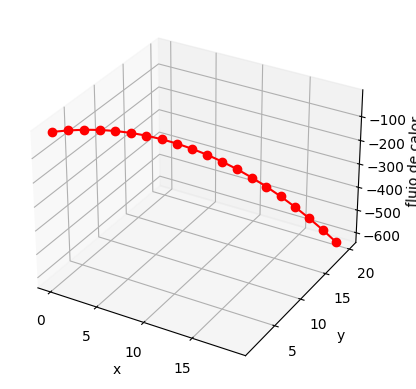

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, c='r', marker='o')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('flujo de calor')
plt.show()


###**2**
 En un cirtcuito con un voltaje de  y una inductancia de L, la primera ley de kirshhoff nos da la siguiente relación
$$\epsilon(t)=L\frac{di}{dt}+Ri$$

donde r, es la resistencia del ciruito, i es la corriente. Suponga que medimos la corriente con varios valores de t y obtenemos:

$$t = 1.00, 1.01, 1.02, 1.03, 1.0$$

$$i = 3.10, 3.12, 3.14, 3.18, 3.24$$

donde t se mide en segundos, i se de en amper, la inductancia L es una constante de 0.98 herios, la resistencia es de 0.142 ohms. Aproxime el votaje  en los valores t=1.00, 1.01, 1.02, 1.03, 1.04 , para ello realice lo siguiente:

**A** Construya un data frame de pandas con los valores de tiempo y corriente


In [ ]:
datos = {"tiempo" : [ 1.00 , 1.01 , 1.02 , 1.03 , 1.04 ] , "corriente" : [3.10 , 3.12 , 3.14 , 3.18 , 3.24]}
datos = pd.DataFrame(datos)
datos

,tiempo,corriente
0,1.00,3.10
1,1.01,3.12
2,1.02,3.14
3,1.03,3.18
4,1.04,3.24


**B** Emplee un metodo calcular la derivada numérica.


In [ ]:
def deriv(datos): #sea datos un dataframe
  h= 0.001
  D = []
  for i in range(len(datos)-1):
    d = ( datos["corriente"].iloc[i+1] - datos["corriente"].iloc[i] ) / ( datos["tiempo"].iloc[i+1] - datos["tiempo"].iloc[i])
    D.append(d)
  return D

In [ ]:
deriv(datos)

[2.0, 2.0, 4.0, 6.0]

**C** Use la ley de kirshhoff para en $\epsilon$ eligiendo un $L$ y $R$ arbitrarios.

In [ ]:
def ley_kirshhoff(L,R , didt):
  e = L*didt + R
  return e

In [ ]:
didt = np.array(deriv(datos))

In [ ]:
ley_kirshhoff(0.98 , 0.142 , didt)

array([2.102, 2.102, 4.062, 6.022])

### **3**
Supongamos que tienes una muestra de material radiactivo y deseas determinar la velocidad a la que disminuye la cantidad de material radioactivo en función del tiempo. El decaimiento radioactivo sigue una ley exponencial y se puede describir mediante la siguiente ecuación:

$$N(t)=N_0e^{-\lambda t}$$

Donde:

$N(t)$ es la cantidad de material radioactivo en el tiempo $t$

$N_0$ es la cantidad inicial de material radioactivo.

$\lambda$ es una constante de decaimiento

$t$ es el tiempo

Para encontrar la tasa de cambio de $N(t)$ con respecto al tiempo $t$, es decir, la velocidad de decaimiento radioactivo, puedes calcular la derivada de $N(t)$ con respecto a $t$:




**A** Encuentre la velocidad de decaimiento usando la libreria simbololica, luego paselo a una libreria numerica y grafique.



In [ ]:
N , t , λ = sp.Symbol("N")  , sp.Symbol("t") , sp.Symbol("λ")
Nt = N*(sp.exp(-(λ*t)))
v = Nt.diff(t)
v_ = sp.lambdify( [ t , N , λ ]  , Nt , 'numpy')
v

-N*λ*exp(-t*λ)

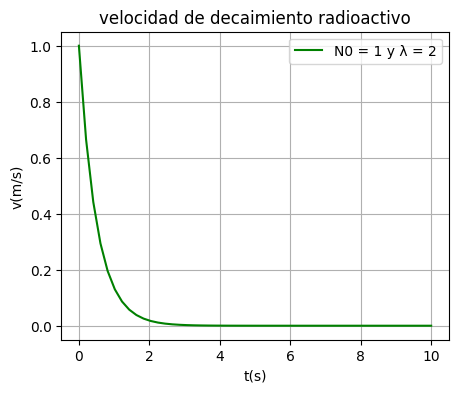

In [ ]:
ti= np.linspace(0,10,50)

plt.figure(figsize=(5,4))
plt.plot( ti , v_(ti , 1 , 2 ) , color = "green" , label = "N0 = 1 y λ = 2")
plt.title("velocidad de decaimiento radioactivo")
plt.ylabel("v(m/s)")
plt.xlabel("t(s)")
plt.legend()
plt.grid()
plt.show()

**B** Encuentre la velocidad de decaimiento, usando la aproximación de la derivada y grafique.

In [ ]:
def derivada( x1 , funcion):
  h = 0.0000000000001
  x = ( funcion(x1+h) - 2*funcion(x1) + funcion(x1-h) ) /  (h**2) #taylor central
  return x

In [ ]:
def Nt(t):
  N0 , λ = 1 , 2
  N = N0*np.exp(-(λ*t))
  return N

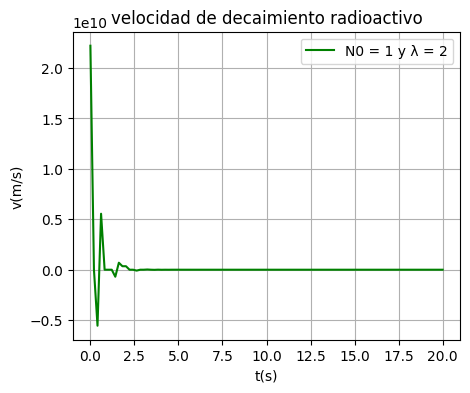

In [ ]:
ti= np.linspace(0,20,100)

plt.figure(figsize=(5,4))
plt.plot( ti , derivada(ti , Nt) , color = "green" , label = "N0 = 1 y λ = 2")
plt.title("velocidad de decaimiento radioactivo")
plt.ylabel("v(m/s)")
plt.xlabel("t(s)")
plt.legend()
plt.grid()
plt.show()

### **4**
Imagina un péndulo simple (una masa suspendida en un hilo) que oscila de un lado a otro. Quieres determinar cómo cambia la aceleración de la masa en función del tiempo durante su oscilación. La aceleración del péndulo en función del ángulo de desplazamiento

θ se puede describir mediante la siguiente ecuación:

$$\frac{d^2θ}{dt^2}+\frac{g}{L}sin(θ)=0$$

$t$ = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

$θ$ = [ 0, 9.6, 18.2, 24.9,28.9, 29.9, 27.7, 22.6,15.1, 6.0, -3.7, -13.0,-21.0, -26.8, -29.7, -29.4,-26.1 , -20.0, -11.7, -2.,7.4]

**A** Grafique la posicion vez el tiempo.

**B** calcule la primera derivada y grafique.

**C** Calcule la segunda derivada y grafique.

In [ ]:
t  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
θ = [ 0, 9.6, 18.2, 24.9,28.9, 29.9, 27.7, 22.6,15.1, 6.0, -3.7, -13.0,-21.0, -26.8, -29.7, -29.4,-26.1 , -20.0, -11.7, -2.,7.4]

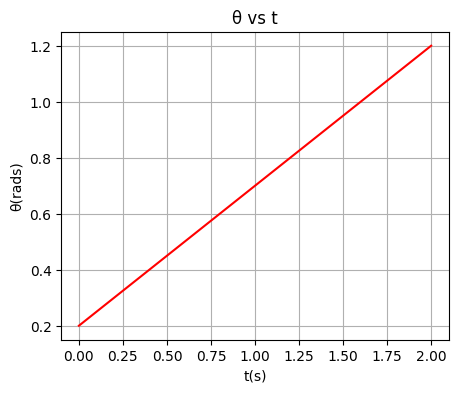

In [ ]:
plt.figure(figsize=(5,4))
plt.plot( t , θ , color = "red")
plt.title("θ vs t")
plt.ylabel("θ(rads)")
plt.xlabel("t(s)")
plt.grid()
plt.show()

In [ ]:
def deriv( x , y):  #x,y listas
  h= 0.001
  D = []
  for i in range(len(x)-1):
    d = ( y[i+1] - y[i] ) / ( x[i+1] - x[i])   #metodo numerico adelante
    D.append(d)
  return D

In [ ]:
dθ = deriv( t , θ)
d2θ = deriv(t[:20] , dθ)

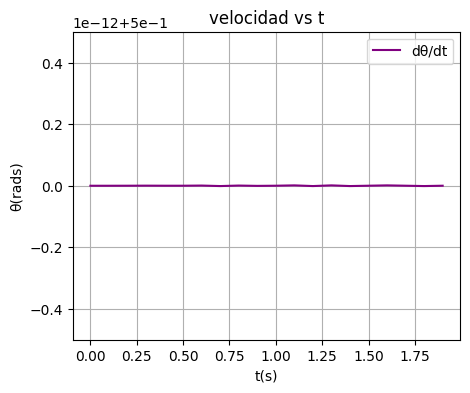

In [ ]:
plt.figure(figsize=(5,4))
plt.plot( t[:20] , dθ , color = "purple" , label = "dθ/dt")
plt.title("velocidad vs t")
plt.ylabel("θ(rads)")
plt.xlabel("t(s)")
plt.legend()
plt.grid()
plt.show()

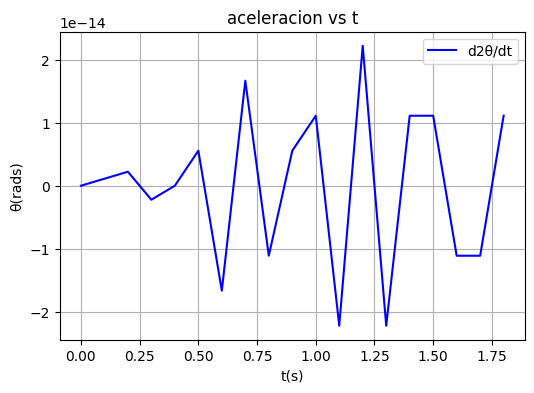

In [ ]:
plt.figure(figsize=(6,4))
plt.plot( t[:19] , d2θ , color = "blue" , label = "d2θ/dt")
plt.title("aceleracion vs t")
plt.ylabel("θ(rads)")
plt.xlabel("t(s)")
plt.legend()
plt.grid()
plt.show()

### **5**
Repita el ejercicio anterior, pero ahora usando la libreria scipy.

In [ ]:
#Interpolacion Metodo de newton
def interpolacion(xi , yi):
  divisores = []
  coeficientes =  []
  filtro = yi

  for k in range(1,len(filtro)+1):
    for i in range(len(filtro)-1):
      y = ( filtro[i+1] - filtro[i] ) / ( xi[i+k] - xi[i] )
      divisores.append(y)

    coeficientes.append(filtro[0])
    filtro = divisores
    divisores = []
  return coeficientes

def funcion(xi , yi , x )
  coeficientes = interpolacion(xi , yi)
  P = coeficientes[0]
  multi = 1
  for i in range(len(xi)-1):
    multi = (x - xi[i]) * multi
    P = P + ( coeficientes[i+1] * multi)
  return P

In [ ]:
ve = derivative(funcion , t , dx = 0.001)
plt.figure(figsize=(5,4))
plt.plot( t , ve , color = "purple" , label = "dθ/dt")
plt.title("velocidad vs t")
plt.ylabel("θ(rads)")
plt.xlabel("t(s)")
plt.legend()
plt.grid()
plt.show()